## Region Proposals with CNN (R-CNN)

The one and only object detection algorithm which propose to select large number of regions from an image. 

Now, these regions are being passed to CNN architecture to predict the bounding boxes and class.

### **How to generate category independent Region proposals.**

Many papers are present for this like : objectness [1], selective search [39],
category-independent object proposals [14], constrained
parametric min-cuts (CPMC) [5], multi-scale combinatorial
grouping [3], and Cires¸an et al. [6], who detect mitotic cells
by applying a CNN to regularly-spaced square crops, which
are a special case of region proposals

### Dataset

We will use [PASCAL VOC 2007](https://www.kaggle.com/datasets/stpeteishii/pascal-voc-2007-dataset/data) Dataset

Expand the downloaded zip file and copy the folder staright to **Object_Detection** folder

In [11]:
import os
from pathlib import Path 

folder_path = Path().absolute().parent
images_path = os.path.join(folder_path, 'VOCdevkit2007/VOC2007/JPEGImages')
annotations_path = os.path.join(folder_path, 'VOCdevkit2007/VOC2007/Annotations')

print(f"Image path : {images_path}")
print(f"Annotations path : {annotations_path}")

Image path : /Users/umesh/Desktop/Computer-Vision-/Object_Detection/VOCdevkit2007/VOC2007/JPEGImages
Annotations path : /Users/umesh/Desktop/Computer-Vision-/Object_Detection/VOCdevkit2007/VOC2007/Annotations


In [12]:
from tqdm import tqdm

# storing images and its annotations
images = []
annotations = []

for filename in tqdm(os.listdir(images_path)):
    images.append(os.path.join(images_path, filename))

for filename in tqdm(os.listdir(annotations_path)):
    annotations.append(os.path.join(annotations_path, filename))

print(f"Total images: {len(images)}")

100%|██████████| 5011/5011 [00:00<00:00, 1780704.68it/s]

Total images: 5011


### **Play with Images** 

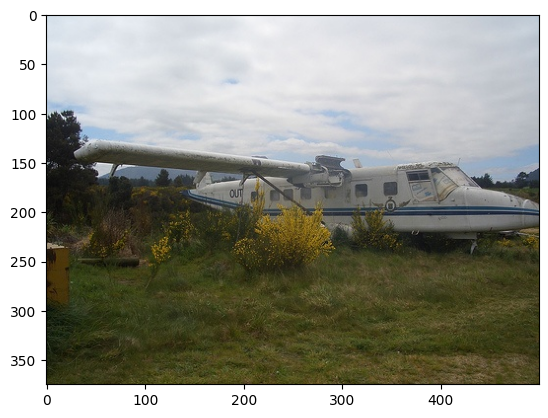

In [23]:
import cv2 
import matplotlib.pyplot as plt

test_image = cv2.imread(images[1])

plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
plt.show()

We are going to use **selective search** for posposing regions. 
- After this each proposed region is passed to CNN which creates a feature map 
- Now this feature map gets passed to object probability detection.

In [24]:
# Run Selective Search
import selectivesearch
img_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

_, regions = selectivesearch.selective_search(img_rgb, scale=500, sigma=0.9, min_size=10)

print(f"Total proposed regions: {len(regions)}")

/Users/umesh/Desktop/Computer-Vision-/myenv/lib/python3.11/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Total proposed regions: 245


In [25]:
regions[0]

{'rect': (0, 0, 499, 152), 'size': 65345, 'labels': [np.float64(0.0)]}

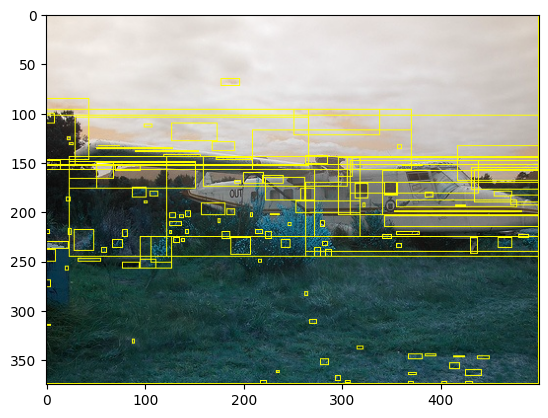

In [33]:
# Draw first 100 region proposals
# for i in range(len(regions)):
for i in range(160):
    x, y, w, h = regions[i]['rect']
    cv2.rectangle(test_image, (x, y), (x+w, y+h), (255, 255, 0), 1)
plt.imshow(test_image)
plt.show()

### Step3

Now we need to pass this region of proposals through a CNN to create a feature vector 

In [34]:
# functions to parse annotation files and get bounding boxes 
import xml.etree.ElementTree as ET
from collections import Counter
import pandas as pd

def parse_annotation(annotation_file_path):
    tree = ET.parse(annotation_file_path)
    root = tree.getroot()

    # image filename
    filename = root.find('filename').text 
    image_path = os.path.join(images_path, filename)

    labels = []
    bounding_boxes = []

    for obj in root.findall('object'):
        label = obj.find('name').text
        labels.append(label)
        bbox = obj.find('bndbox')
        x_min = int(bbox.find('xmin').text)
        y_min = int(bbox.find('ymin').text)
        x_max = int(bbox.find('xmax').text)
        y_max = int(bbox.find('ymax').text) 
        bounding_boxes.append((x_min, y_min, x_max, y_max))

    return image_path, labels, bounding_boxes 

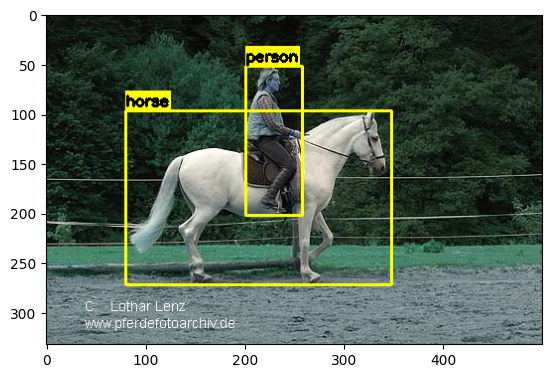

In [39]:
# sample chacking this function to parse annotation file 
img_path, labels, bboxes = parse_annotation(annotations[1])

img_test = cv2.imread(img_path)

for label, bbox in zip(labels, bboxes):
    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_test, (x_min, y_min), (x_max, y_max), (255, 255, 0), 2)

    text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]
    cv2.rectangle(img_test, (x_min, y_min - 20), (x_min + text_size[0], y_min), (255, 255, 0), -1)
    cv2.putText(img_test, label, (x_min, y_min - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)
    
plt.imshow(img_test)
plt.show()

In [ ]:
labels = []

In [45]:
from torch.utils.data import Dataset, DataLoader 
from PIL import Image 

# if root directory 
class CustomDataset(Dataset):
    def __init__(self, annotations_path, transform=None):
        self.annotations_path = annotations_path

    def __len__(self):
        return len(self.annotations_path)
    
    def __getitem__(self, idx):
        image_path, labels, boxes = parse_annotation(self.annotations_path[idx])
        image = Image.open(image_path).convert("RGB")
        target = {
            'labels' : labels,
            'boxes' : boxes
        }
        return image, target
    
# creating dataset 
dataset = CustomDataset(annotations, transform=None)
print(f"Total number of samples in dataset : {len(dataset)}")

Total number of samples in dataset : 5011


Now write the functons which takes an image and returns the proposed regions with gorund truth classes to get the CNN, SVM and bounding box regressor trained

### Build a CNN architecture to get feature vector of images 

In [46]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.batchnorm1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.batchnorm2 = nn.BatchNorm2d(32)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)

    def forward(self, x):
        x = self.pool(F.relu(self.batchnorm1(self.conv1(x))))
        x = self.pool(F.relu(self.batchnorm2(self.conv2(x))))
        x = x.view(-1, 32 * 56 * 56)
        x = F.relu(self.fc1(x))
        return x    